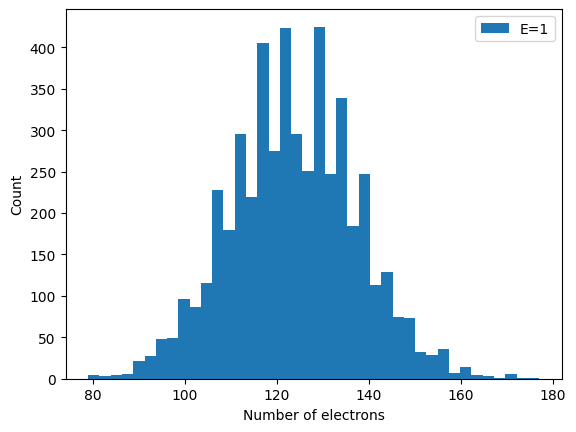

In [26]:
import numpy as np
import matplotlib.pyplot as plt

m,cm=1,0.01
class Detector():
    def __init__(self, R=2*m,N=40,r=10*cm, prob=0.5):
        self.R=R
        self.N=N
        self.r=r
        self.prob=prob
    def random_distribution(self):
        phi=np.random.uniform(0,2*np.pi, self.N)
        cosTheta=np.random.uniform(-1,1,self.N)
        sinTheta=np.sqrt(1-cosTheta*cosTheta)
        return self.R*np.array([sinTheta*np.cos(phi),sinTheta*np.sin(phi), cosTheta])
    def IsInPMT(self,origin:np.ndarray,PhotonArray:np.ndarray, PMTarray:np.ndarray):
        cosMax=np.cos(self.r/self.R)
        cosCheck=(origin[:, None] + PhotonArray).T@PMTarray
        return np.any(cosCheck>(self.R**2)*cosMax, axis=1)
        
    def ElectronYield(self, NDetected:float):
        return np.random.poisson(self.prob * NDetected) #по свойству распределения пуассона 



class Source():
    def __init__(self, E:np.ndarray,origin:np.ndarray,Y=1e4):
        self.Y=Y
        self.N=int(E*Y)
        self.origin=origin
    def random_distribution(self):
        phi=np.random.uniform(0,2*np.pi, self.N)
        cosTheta=np.random.uniform(-1,1,self.N)
        sinTheta=np.sqrt(1-cosTheta*cosTheta)
        return np.array([sinTheta*np.cos(phi),sinTheta*np.sin(phi), cosTheta])
    def distance_traversed(self,PhotonArray:np.ndarray,R:float):
        self.origin=np.reshape(self.origin,(1,3))
        t=-self.origin@PhotonArray+np.sqrt(R**2-np.sum(self.origin**2)+(self.origin@PhotonArray)*(self.origin@PhotonArray))
        return t

 
D1=Detector()
PMTarray=D1.random_distribution()
origin=np.array([0,0,0])


EventCount=1000
def Event(E:float, EventCount:int, origin:np.array):
    S1=Source(E,origin)
    N_e = []
    #все фотоны долетают до ФЭУ
    for i in range(EventCount):
        PhotonArray=S1.random_distribution()
        PhotonArray*=S1.distance_traversed(PhotonArray,D1.R)
        registered=np.sum(D1.IsInPMT(origin,PhotonArray,PMTarray))
        N_e.append(D1.ElectronYield(registered))
    return np.array(N_e)            

def plotter(N_e:np.array):
    for i in range(len(Elist)):
        plt.hist(N_e[i], bins=40, label=f"E={Elist[i]}")
    plt.legend()
    plt.xlabel("Number of electrons")
    plt.ylabel("Count")
    plt.show()
        
Elist=[1]
N_e = np.array([Event(E, EventCount,origin) for E in Elist])

plotter(N_e)



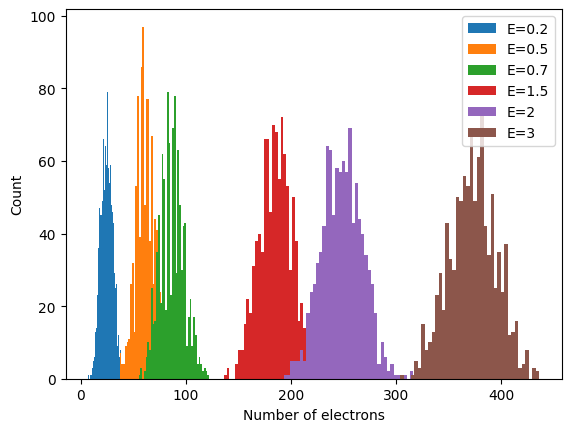

In [2]:
Elist=[0.2,0.5,0.7,1.5,2,3]
N_e = np.array([Event(E, EventCount,origin) for E in Elist])

plotter(N_e)


Для более наглядного представления зависимости ширины распределения от Е события все распределения из списка построены на одном графике. С ростом энергии увеличивается ширина распределения

Дальше представлены распределения для смещенного на 1 м источника 

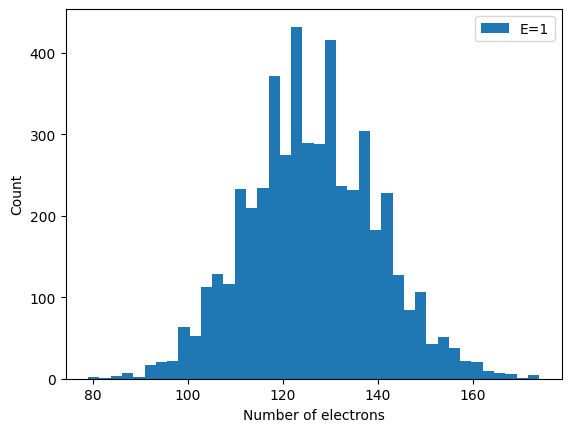

In [27]:
origin=np.array([0,0,1])
Elist=[1]
N_e = np.array([Event(E, EventCount,origin) for E in Elist])

plotter(N_e)

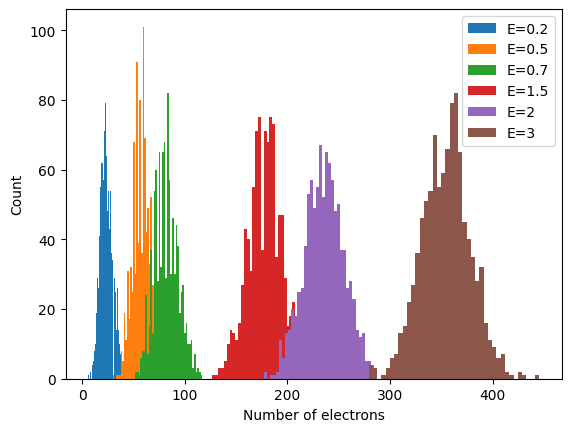

In [17]:
origin=np.array([0,0,1])
Elist=[0.2,0.5,0.7,1.5,2,3]
N_e = np.array([Event(E, EventCount,origin) for E in Elist])

plotter(N_e)

In [ ]:
Из сравнения распределений для источника, помещенного в центре сферы, и смещенного источника следует, что распределения почти не зависят от сдвига. 